In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
aapl_df = pd.read_csv(r"E:\Pyhton code\Data Sets\archive\stock price data\stocks\AAPL.csv")

In [3]:
aapl_df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


In [4]:
print(aapl_df.shape)
print(aapl_df.info())
print(aapl_df.describe())

(9909, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9909 entries, 0 to 9908
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9909 non-null   object 
 1   Open       9909 non-null   float64
 2   High       9909 non-null   float64
 3   Low        9909 non-null   float64
 4   Close      9909 non-null   float64
 5   Adj Close  9909 non-null   float64
 6   Volume     9909 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 542.0+ KB
None
              Open         High          Low        Close    Adj Close  \
count  9909.000000  9909.000000  9909.000000  9909.000000  9909.000000   
mean     32.606849    32.936079    32.277560    32.618030    30.576570   
std      58.415759    59.001576    57.883037    58.471899    56.746275   
min       0.198661     0.198661     0.196429     0.196429     0.155638   
25%       1.071429     1.089286     1.048571     1.071429     0.917643   
50%       1

Insights:
- Date columns need to be converted into datetime format
- Data do not have any missing values
- There are high outliers in all most every column
- The distribution of the data is skewed, with most values concentrated in the lower range

In [6]:
aapl_df.isnull().sum()/len(aapl_df)*100

Date         0.0
Open         0.0
High         0.0
Low          0.0
Close        0.0
Adj Close    0.0
Volume       0.0
dtype: float64

In [13]:
aapl_df.dropna(inplace=True)

In [7]:
aapl_df.duplicated().sum()

np.int64(0)

In [8]:
aapl_df.dtypes

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

In [9]:
aapl_df["Date"] = pd.to_datetime(aapl_df["Date"])

In [11]:
aapl_df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [14]:
#Feature engineering
aapl_df["Return"] = aapl_df["Close"].pct_change()

aapl_df["Volatility"] = aapl_df["High"] - aapl_df["Low"]

aapl_df["Open_Close_Diff"] = aapl_df["Open"] - aapl_df["Close"]

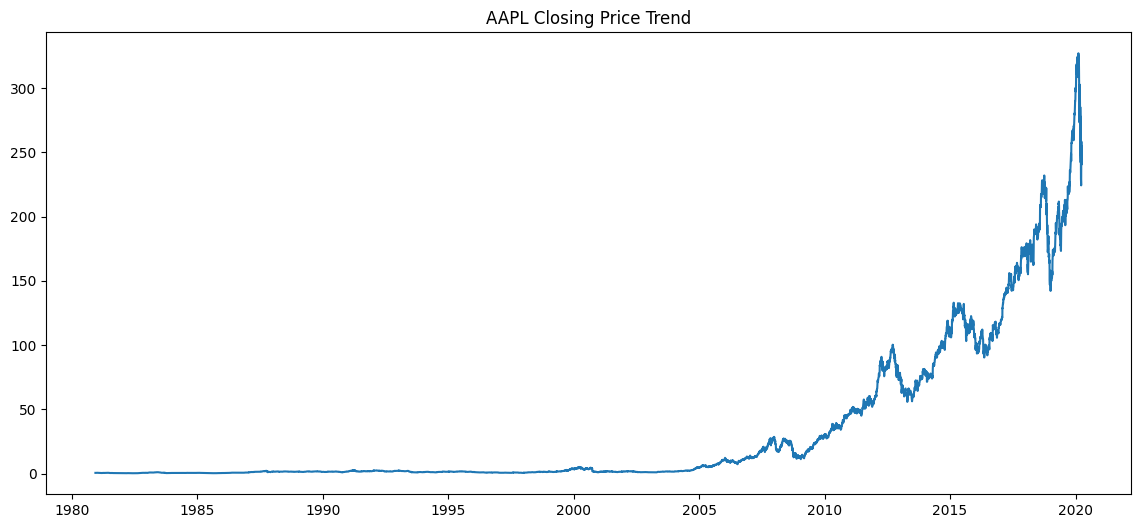

In [15]:
#Univariate analysis
plt.figure(figsize=(14,6))
plt.plot(aapl_df['Date'], aapl_df["Close"])
plt.title("AAPL Closing Price Trend")
plt.show()

<Axes: xlabel='Return', ylabel='Count'>

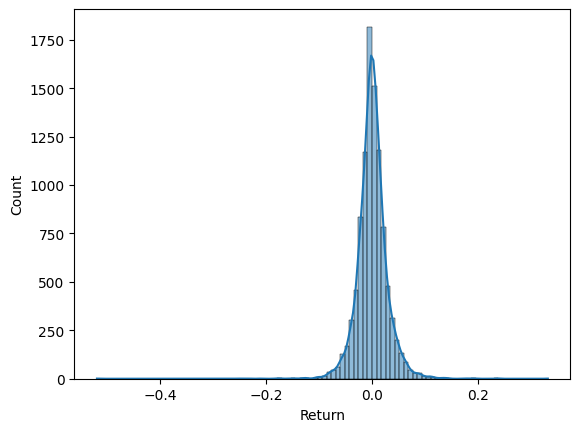

In [16]:
sns.histplot(aapl_df["Return"], bins=100, kde=True)

<Axes: xlabel='Volume', ylabel='Count'>

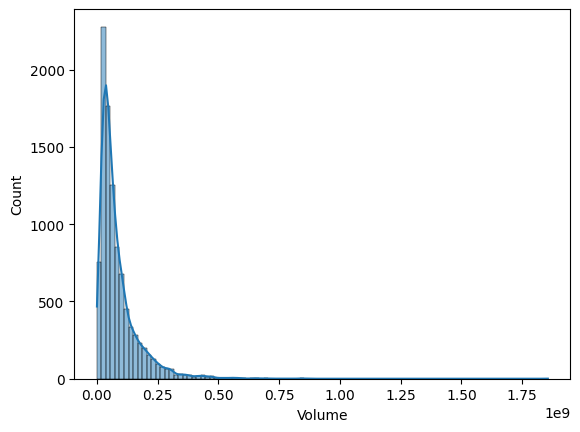

In [19]:
sns.histplot(aapl_df["Volume"], bins=100, kde=True)

<Axes: xlabel='Return'>

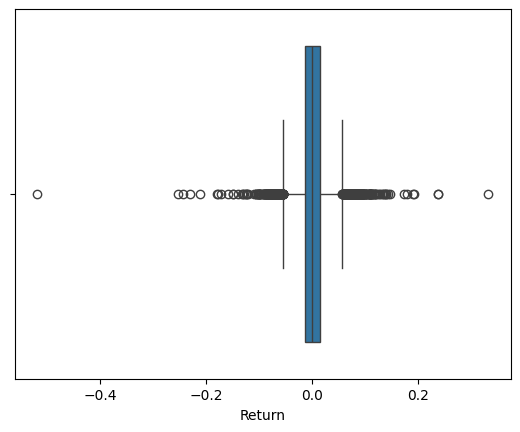

In [20]:
sns.boxplot(x=aapl_df["Return"])

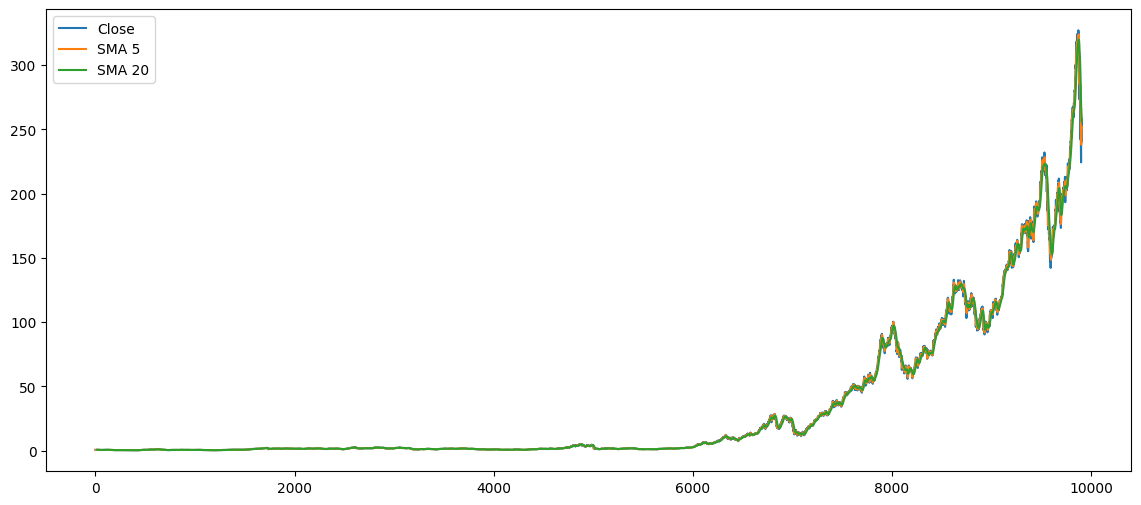

In [22]:
aapl_df["SMA_5"] = aapl_df["Close"].rolling(5).mean()

aapl_df["SMA_20"] = aapl_df["Close"].rolling(20).mean()

plt.figure(figsize=(14,6))

plt.plot(aapl_df["Close"], label="Close")

plt.plot(aapl_df["SMA_5"], label="SMA 5")

plt.plot(aapl_df["SMA_20"], label="SMA 20")

plt.legend()

1️⃣ Closing Price Trend

Observations:
- AAPL stock shows a strong long-term upward trend.
- Rapid growth observed after 2010.
- Sharp drops/crashes visible during some periods.
- Variance increases over time.

Insights:
- Stock price is non-stationary.
- Raw stock price is not ideal directly for Linear Regression.
- Market contains trend + volatility.

2️⃣ Return Distribution

Observations:
- Returns are centered near 0.
- Most daily returns are small.
- Heavy tails are present.
- Extreme positive and negative returns exist.

Insights:
- Returns are more stable than stock prices.
- Presence of outliers indicates market shocks/crashes.
- Data is not perfectly normally distributed.

3️⃣ Volume Distribution

Observations:
- Distribution is highly right-skewed.
- Most trading days have lower volume.
- Few days contain extremely high trading activity.

Insights:
- Certain events/news create sudden spikes in trading.
- Volume contains outliers.
- Log transformation may help later.

4️⃣ Return Boxplot

Observations:
- Many outliers present on both sides.
- Extreme negative returns are visible.
- Extreme positive returns also exist.

Insights:
- Stock market data is highly volatile.
- Outliers are natural in financial data.
- Removing all outliers may not be correct because crashes are real events.

5️⃣ Moving Average Plot (SMA 5 & SMA 20)

Observations:
- Moving averages smooth the price fluctuations.
- SMA 5 follows price closely.
- SMA 20 captures longer-term trend.
- Crossovers between SMA lines are visible.

Insights:
- Moving averages reduce noise.
- Trend becomes easier for Linear Regression to learn.
- SMA features will be useful in feature engineering.

<Axes: xlabel='Volume', ylabel='Return'>

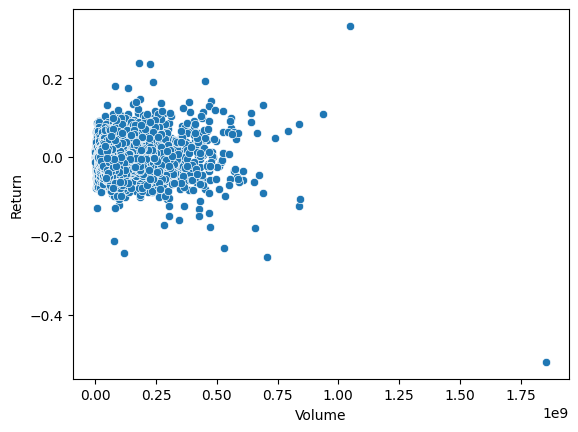

In [23]:
#Bivariate Analysis
sns.scatterplot(x=aapl_df["Volume"], y=aapl_df["Return"])

<Axes: xlabel='Volatility', ylabel='Return'>

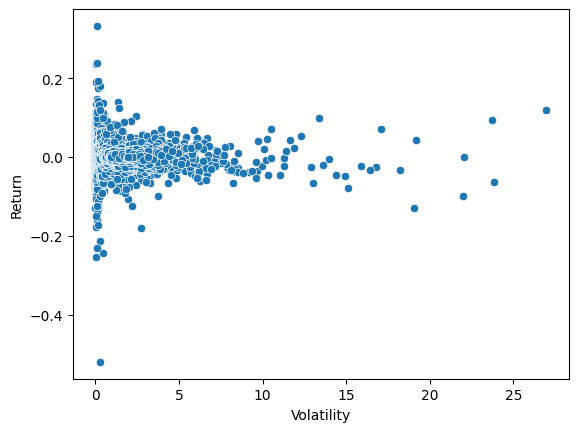

In [24]:
sns.scatterplot(x=aapl_df["Volatility"], y=aapl_df["Return"])

<Axes: xlabel='Open', ylabel='Close'>

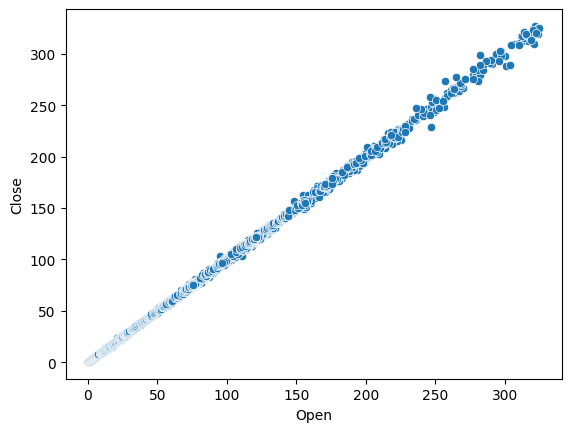

In [25]:
sns.scatterplot(x=aapl_df["Open"], y=aapl_df["Close"])

<Axes: >

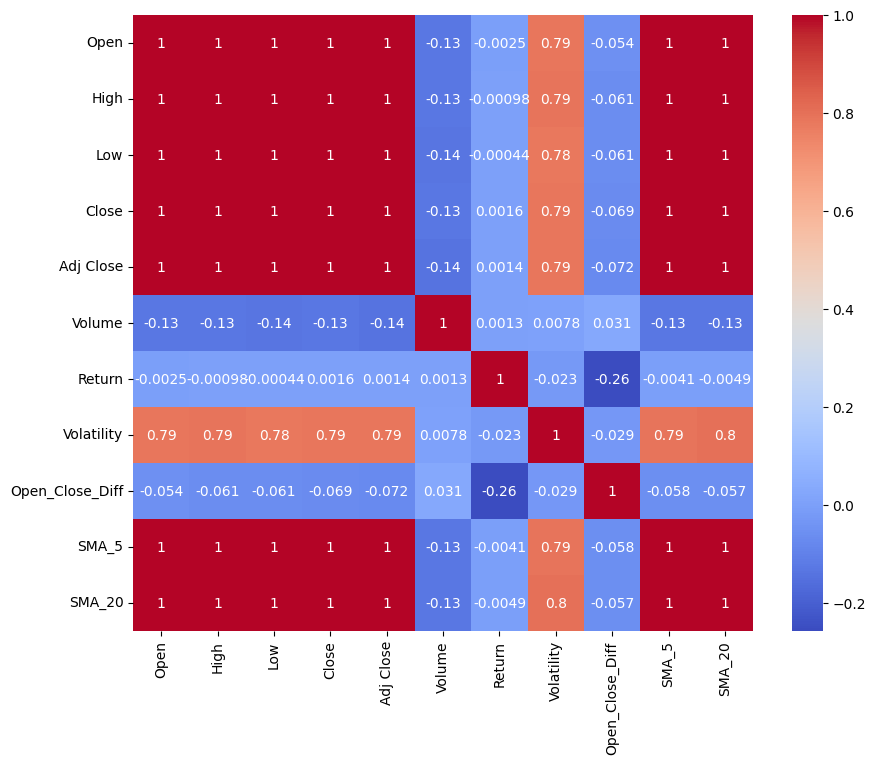

In [26]:
corr = aapl_df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")

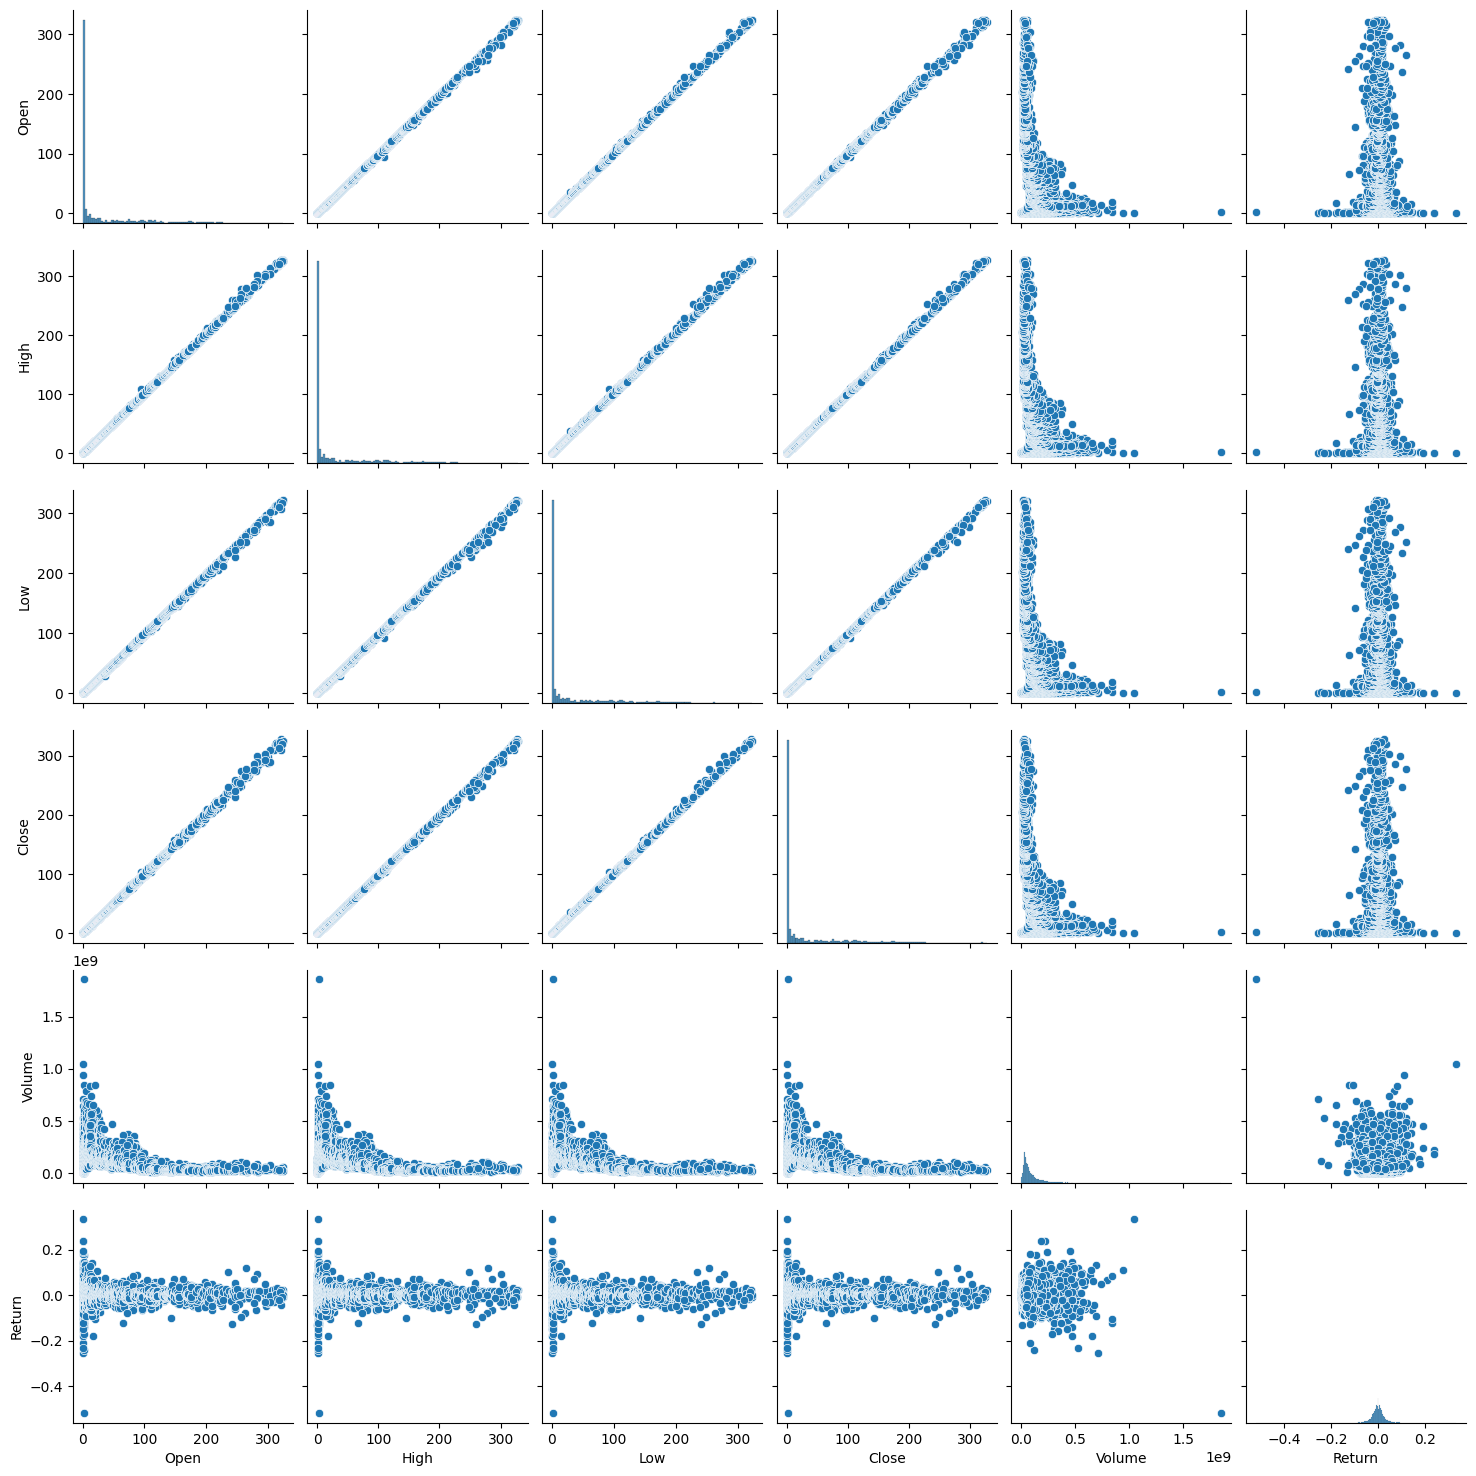

In [27]:

#Multivariate Analysis
sns.pairplot(aapl_df[[
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Return"
]])

1️⃣ Stock Price Behavior:
- AAPL stock shows a strong long-term upward trend.
- Price growth becomes very rapid after 2010.
- Market contains sudden crashes and sharp jumps.
- Raw stock prices are non-stationary.

Insight:
- Direct stock price prediction is difficult for Linear Regression.

2️⃣ Return Analysis:
- Daily returns are centered around 0.
- Most returns are small.
- Heavy tails and extreme returns are present.
- Returns contain many outliers.

Insight:
- Returns are more stable and better suited for regression modeling.

3️⃣ Volume Analysis
- Volume distribution is highly right-skewed.
- Some trading days have extremely high volume spikes.
- High trading activity often occurs during volatile periods.

Insight:
- Volume may help capture market activity and volatility behavior.

4️⃣ Volatility Analysis
- High volatility periods contain wider return spread.
- Extreme volatility corresponds to unstable market behavior.
- Many outliers exist during crash periods.

Insight:
- Stock market data is noisy and highly volatile.

5️⃣ Open vs Close Relationship
- Open and Close prices show nearly perfect linear relation.
- Strong positive relationship exists among Open, High, Low, Close.

Insight:
- Strong multicollinearity exists between price-related features.

6️⃣ Correlation Heatmap Insights
- OHLC features are almost perfectly correlated.
- SMA_5 and SMA_20 are also highly correlated with Close price.
- Return has weak correlation with most features.
- Open_Close_Diff has slight negative relation with Return.

Insight:
- Ridge/Lasso regression will be useful to handle multicollinearity.

7️⃣ Pairplot Insights
- Most price-related features follow strong linear relationships.
- Volume and Return distributions are highly skewed.
- Returns show clustering around zero.
- Outliers are clearly visible.

Insight:
- Financial data contains nonlinear noise, outliers, and unstable variance.

In [29]:
#Sort data based on data time
aapl_df.sort_values("Date", inplace=True)
aapl_df.reset_index(drop=True, inplace=True)

In [30]:
aapl_df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Return,Volatility,Open_Close_Diff,SMA_5,SMA_20
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400,NaN,0.002232,0.000000,NaN,NaN
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200,-0.052174,0.002232,0.002232,NaN,NaN
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000,-0.073394,0.002232,0.002232,NaN,NaN
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400,0.024752,0.002232,0.000000,NaN,NaN
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400,0.028986,0.002232,0.000000,0.477679,NaN


In [32]:
aapl_df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Return',
       'Volatility', 'Open_Close_Diff', 'SMA_5', 'SMA_20'],
      dtype='object')

In [ ]:
#Lag Features
aapl_df["Lag_1"] = aapl_df["Return"].shift(1)

aapl_df["Lag_2"] = aapl_df["Return"].shift(2)

aapl_df["Lag_5"] = aapl_df["Return"].shift(5)
#Lag features help model learn temporal dependency.

In [34]:
#Exponential Moving Average (Gives more importance to recent data)
aapl_df["EMA_10"] = (
    aapl_df["Close"]
    .ewm(span=10)
    .mean()
)

In [35]:
#Rolling volatility (Captures market risk and instability)
aapl_df["Rolling_Volatility"] = (
    aapl_df["Return"]
    .rolling(window=20)
    .std()
)

In [36]:
aapl_df.isnull().sum()

Date                   0
Open                   0
High                   0
Low                    0
Close                  0
Adj Close              0
Volume                 0
Return                 1
Volatility             0
Open_Close_Diff        0
SMA_5                  4
SMA_20                19
Lag_1                  2
Lag_2                  3
Lag_5                  6
EMA_10                 0
Rolling_Volatility    20
dtype: int64

In [37]:
aapl_df.dropna(inplace=True)

In [ ]:
#Creating target variable (To predict next day return)
aapl_df["Target"] = (
    aapl_df["Close"]
    .pct_change()
    .shift(-1) # use today's info to predict tomorrow's return
)

In [39]:
aapl_df.dropna(inplace=True)

In [40]:
#Define X AND y
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Volatility",
    "Open_Close_Diff",
    "SMA_5",
    "SMA_20",
    "EMA_10",
    "Lag_1",
    "Lag_2",
    "Lag_5",
    "Rolling_Volatility"
]
X = aapl_df[features]

y = aapl_df["Target"]

In [44]:
#Time Series Split
split_index = int(len(aapl_df)*0.8)
x_train = X[:split_index]
x_test = X[split_index:]
y_train = y[:split_index]
y_test = y[split_index:]
#Because, future data should never train poast data, random split cuase data leakage

In [45]:
#Feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [46]:
from sklearn.linear_model import LinearRegression

In [47]:
model = LinearRegression()
model.fit(x_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
y_pred = model.predict(x_test_scaled)

In [54]:
#Using ridge regression
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(x_train_scaled, y_train)
y_pred_ridge = ridge.predict(x_test_scaled)

In [55]:
#train lasso regression
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.001)
lasso.fit(x_train_scaled, y_train)
y_pred_lasso = lasso.predict(x_test_scaled)

In [56]:
def evaluate_model(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name}")

    print("-" * 30)

    print("MAE :", mae)

    print("RMSE:", rmse)

    print("R2  :", r2)

In [58]:
evaluate_model(y_test, y_pred, "Linear Regression")

evaluate_model(y_test, y_pred_ridge, "Ridge Regression")

evaluate_model(y_test, y_pred_lasso, "Lasso Regression")


Linear Regression
------------------------------
MAE : 0.013714669600013848
RMSE: 0.0199171877847948
R2  : -0.32211003125133875

Ridge Regression
------------------------------
MAE : 0.012563352247781188
RMSE: 0.01887685152217171
R2  : -0.1876013537835033

Lasso Regression
------------------------------
MAE : 0.011813585418862705
RMSE: 0.017326610261523646
R2  : -0.0005499568717051151


In [60]:
#Compare Coefficients
pd.Series(
    model.coef_,
    index=features
).sort_values()

Close                -0.109069
Open                 -0.108983
SMA_5                -0.083108
SMA_20               -0.040979
Lag_2                -0.001185
Lag_1                -0.001127
Rolling_Volatility   -0.000744
Volatility            0.000274
Lag_5                 0.000336
Volume                0.000554
Open_Close_Diff       0.000633
EMA_10                0.097035
High                  0.120992
Low                   0.123602
dtype: float64

In [61]:
pd.Series(
    ridge.coef_,
    index=features
).sort_values()

SMA_5                -0.016444
Close                -0.009788
Open                 -0.009771
SMA_20               -0.005209
EMA_10               -0.002032
Lag_2                -0.001161
Lag_1                -0.001058
Rolling_Volatility   -0.000721
Volatility           -0.000515
Lag_5                 0.000294
Open_Close_Diff       0.000589
Volume                0.000651
High                  0.021442
Low                   0.021920
dtype: float64

In [62]:
pd.Series(
    lasso.coef_,
    index=features
).sort_values()

Lag_2                -0.000068
Open                  0.000000
Low                   0.000000
High                  0.000000
Volume                0.000000
Volatility           -0.000000
Open_Close_Diff       0.000000
Close                 0.000000
SMA_5                 0.000000
SMA_20                0.000000
EMA_10                0.000000
Lag_1                -0.000000
Lag_5                 0.000000
Rolling_Volatility   -0.000000
dtype: float64

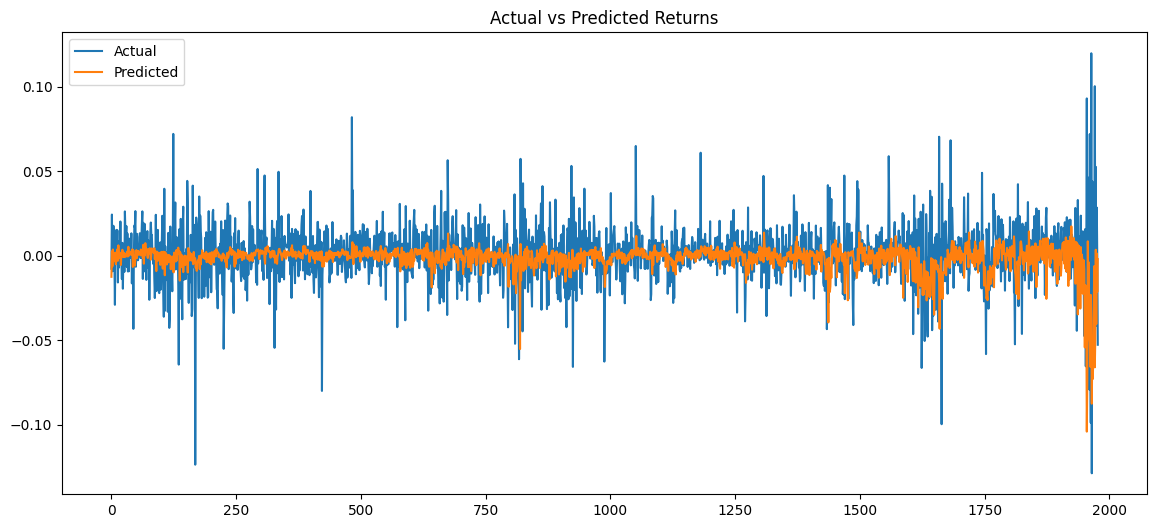

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    y_pred_ridge,
    label="Predicted"
)

plt.legend()

plt.title("Actual vs Predicted Returns")

plt.show()

Key Findings

1️⃣ Stock returns are highly noisy and difficult to predict using simple linear models.

2️⃣ Strong multicollinearity exists among OHLC price features.

3️⃣ Ridge Regression stabilized coefficients and improved generalization.

4️⃣ Lasso Regression performed best by removing redundant/noisy features.

5️⃣ Financial markets contain nonlinear and stochastic behavior beyond simple linear assumptions.

Overall Report:

- Title: AAPL Stock Trend Predictor - Linear Regression Analysis

- Dataset shape: (2520, 10)

Steps:
- Data cleaning
- Data Analysis (univariate, bivariate, multivariate)
- Data engineering
- Time series splitting
- Modeling (linear, ridge, lasso regression)
- Metrics evaluation (MAE, MSE, R²)

- Final Model: Lasso Regression with alpha=0.001

Final Performance:
- MAE : 0.011813585418862705
- RMSE: 0.017326610261523646
- R2  : -0.0005499568717051151